# Zero Noise Extrapolation

The `propaq.noise` module provides functionality to simulate quantum circuits with user-defined noise models, the default being a simple depolarizing noise model. By propagating an observable through a noisy circuit where the noise strength is varied, one can extrapolate the expectation value of the observable to the zero-noise limit, known as zero-noise extrapolation (ZNE)$^{[1,2]}$. propaq implements a simple ZNE class 
that can be used to perform this extrapolation.

For this example, we will be estimating the ground-state energy of a simple hydrogen molecule using the LUCJ ansatz. We will first define the Hamiltonian and the ansatz circuit, and then we will use the ZNE class to perform the extrapolation.

In [ ]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.providers.fake_provider import GenericBackendV2

atom: str = "H"
natoms: int = 2
nlayers: int = 1

def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.

    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

# Specify molecule properties
spin_sq = 0

# Build molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

print(f"norb = {norb}")
print(f"nelec = {nelec}")

# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

import warnings

from qiskit.transpiler import CouplingMap

warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

# Set ansatz properties
n_reps = nlayers
pairs_aa = [(p, q) for p in range(norb) for q in range(p + 1, norb)]
pairs_ab = None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

# Initialize backend — use exactly 2*norb qubits so transpilation adds no ancilla
# qubits and physical qubit indices match the molecular spin-orbital ordering.
coupling_map = CouplingMap.from_full(2 * norb, bidirectional=True)
backend = GenericBackendV2(
    2 * norb,
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

# Create pass manager
try:
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="heavy-hex",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )
    print("Unable to generate ffsim pass manager")
except RuntimeError:
    pass_manager = None

# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    options=dict(maxiter=10_000),
)

# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
# circuit.measure_all()

if pass_manager is not None:
    compiled = pass_manager.run(circuit)
else:
    compiled = qiskit.transpile(
        circuit, backend=backend, optimization_level=3,
        initial_layout=list(range(2 * norb)),
    )

print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

compiled.draw(fold=-1)

Let's build the hamiltonian for a simple hydrogen molecule.

In [6]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp

h2e_phys = np.einsum("prqs->pqrs", eri)  # chemist -> physicist notation
elec_ints = ElectronicIntegrals.from_raw_integrals(hcore, h2e_phys)
elec_hamiltonian = ElectronicEnergy(elec_ints)
mapper = JordanWignerMapper()
hamiltonian = mapper.map(elec_hamiltonian.second_q_op())
hamiltonian = (hamiltonian + SparsePauliOp("I" * (2 * norb), coeffs=[nuclear_repulsion_energy])).simplify()
sorted_indices = np.argsort(-np.abs(hamiltonian.coeffs))
hamiltonian = hamiltonian[sorted_indices]
print(f"Hamiltonian has {len(hamiltonian)} Pauli terms.")

Hamiltonian has 15 Pauli terms.


Now, let's convert it to a `MajoranaTermSum` so that we can use it with propaq. We will also build the ZNE object.

In [7]:
from propaq.datatypes import MajoranaMonomial, MajoranaTermSum
from propaq.propagators import MajoranaPropagator
from propaq.circuits import MajoranaCircuit
from propaq.noise import UniformNoiseModel, TruncationPolicy
from propaq.extrapolators import ZeroNoiseExtrapolator

obs_ham = MajoranaTermSum.from_sparse_pauli_op(hamiltonian)
mc = MajoranaCircuit.from_qiskit(compiled.copy(), n_modes=4 * norb)

prop_ham = MajoranaPropagator(
        UniformNoiseModel(damping=0.00),
        TruncationPolicy(weight_cutoff=None, coeff_cutoff=1e-10, truncation_range=(None, 10_000_000)),
        n_threads=16,
        progress_bar=False,
)

Now, let's define some noise levels and perform the extrapolation.

LUCJ energy (propaq) : -1.108869 Ha
LUCJ energy (ZNE)    : -1.108635 Ha
HF energy            : -1.073583 Ha  (upper bound)
CCSD energy          : -1.108873 Ha  (reference)


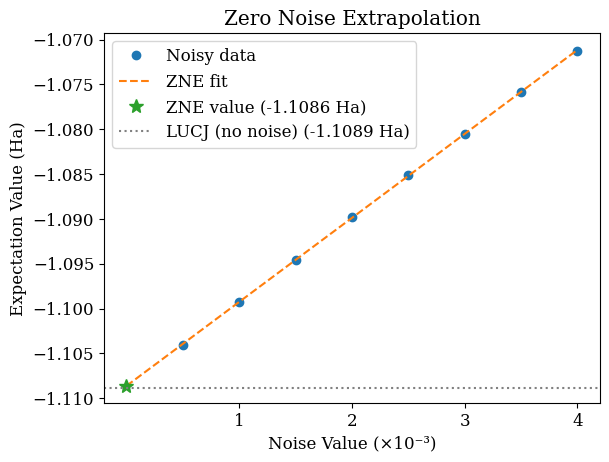

In [8]:
result_ham = prop_ham.expectation_value(obs_ham, mc, fock_state=0) # Noiseless LUCJ value for reference

zne = ZeroNoiseExtrapolator(
    fitting_fn=lambda x, a, b: a + b * x,
    noise_values=[0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035, 0.004],
)

result_zne = zne.run(
      prop_ham, 
      obs_ham,
      mc,
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Data points
ax.plot(result_zne.noise_values, result_zne.expectation_values, 'o', label='Noisy data')

# Fit line from zero to max noise, extrapolated back to x=0
noise_range = np.linspace(0, max(result_zne.noise_values), 200)
fit_curve = [zne.fitting_fn(x, *result_zne.fit_params) for x in noise_range]
ax.plot(noise_range, fit_curve, '--', label='ZNE fit')

# Mark the extrapolated zero-noise value
ax.plot(0, result_zne.zero_noise_value, '*', markersize=10, label=f'ZNE value ({result_zne.zero_noise_value:.4f} Ha)')

# Horizontal line at the noiseless LUCJ value
ax.axhline(result_ham.expectation_value, color='gray', linestyle=':', label=f'LUCJ (no noise) ({result_ham.expectation_value:.4f} Ha)')

ax.set_xticks([0.001, 0.002, 0.003, 0.004])
ax.set_xticklabels(['1', '2', '3', '4'])
ax.set_xlabel('Noise Value (×10⁻³)')
ax.set_ylabel('Expectation Value (Ha)')
ax.set_title('Zero Noise Extrapolation')
ax.legend()

print(f"LUCJ energy (propaq) : {result_ham.expectation_value:.6f} Ha")
print(f"LUCJ energy (ZNE)    : {result_zne.zero_noise_value:.6f} Ha")
print(f"HF energy            : {scf.e_tot:.6f} Ha  (upper bound)")
print(f"CCSD energy          : {ccsd.e_tot:.6f} Ha  (reference)")

# Citations

> [1] K. Temme, S. Bravyi, and J. M. Gambetta, “Error mitigation for short-depth quantum circuits,” Phys. Rev. Lett., vol. 119, no. 18, p. 180509, Nov. 2017, doi: 10.1103/PhysRevLett.119.180509.

> [2] Y. Li and S. C. Benjamin, “Efficient Variational Quantum Simulator Incorporating Active Error Minimization,” Phys. Rev. X, vol. 7, no. 2, p. 021050, Jun. 2017, doi: 10.1103/PhysRevX.7.021050.
